# Olist — Repeat Customer EDA

Deep-dive into customer retention, repeat purchase behaviour, RFM segmentation, cohort analysis, and churn risk.

---
**Sections**
1. [Setup & Data Loading](#1)
2. [Repeat Purchase Overview](#2)
3. [Purchase Frequency Distribution](#3)
4. [Revenue Contribution](#4)
5. [Time Between Purchases](#5)
6. [RFM Segmentation](#6)
7. [Cohort Retention Analysis](#7)
8. [Geographic Breakdown](#8)
9. [Churn Risk Identification](#9)
10. [Key Insights](#10)

## 1. Setup & Data Loading <a id='1'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.family':      'sans-serif',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
    'axes.titleweight': 'bold',
})

C = {
    'blue':   '#378ADD',
    'teal':   '#1D9E75',
    'coral':  '#D85A30',
    'purple': '#534AB7',
    'amber':  '#BA7517',
    'pink':   '#D4537E',
    'gray':   '#888780',
    'navy':   '#185FA5',
    'red':    '#E24B4A',
}
print('Setup complete ✓')

Setup complete ✓


In [2]:
DATA = 'data/'  # adjust if your CSVs are elsewhere

orders      = pd.read_csv(f'{DATA}olist_orders_dataset.csv',
                  parse_dates=['order_purchase_timestamp',
                               'order_approved_at',
                               'order_delivered_customer_date',
                               'order_estimated_delivery_date'])
customers   = pd.read_csv(f'{DATA}olist_customers_dataset.csv')
payments    = pd.read_csv(f'{DATA}olist_order_payments_dataset.csv')
order_items = pd.read_csv(f'{DATA}olist_order_items_dataset.csv')
reviews     = pd.read_csv(f'{DATA}olist_order_reviews_dataset.csv')

print('Datasets loaded:')
for name, df in [('orders', orders), ('customers', customers),
                 ('payments', payments), ('order_items', order_items)]:
    print(f'  {name:<15} {df.shape[0]:>8,} rows')

Datasets loaded:
  orders            99,441 rows
  customers         99,441 rows
  payments         103,886 rows
  order_items      112,650 rows


In [3]:
# ── Build master customer table ──────────────────────────────────────────
# Join customer_id -> customer_unique_id so we can track the same person
# across multiple orders (Olist assigns a new customer_id per order)
orders_cust = orders.merge(
    customers[['customer_id', 'customer_unique_id', 'customer_state',
                'customer_city', 'customer_zip_code_prefix']],
    on='customer_id', how='left'
)

# Aggregate payment value per order
order_value = payments.groupby('order_id')['payment_value'].sum().reset_index()
order_value.columns = ['order_id', 'order_value']

orders_cust = orders_cust.merge(order_value, on='order_id', how='left')

# Per-customer summary
customer_df = orders_cust.groupby('customer_unique_id').agg(
    total_orders    = ('order_id',                'count'),
    total_spend     = ('order_value',             'sum'),
    avg_order_value = ('order_value',             'mean'),
    first_order_at  = ('order_purchase_timestamp','min'),
    last_order_at   = ('order_purchase_timestamp','max'),
    customer_state  = ('customer_state',          'first'),
    customer_city   = ('customer_city',           'first'),
).reset_index()

customer_df['is_repeat']      = customer_df['total_orders'] > 1
customer_df['days_as_customer'] = (
    customer_df['last_order_at'] - customer_df['first_order_at']
).dt.days

print(f'Unique customers (customer_unique_id): {len(customer_df):,}')
print(f'One-time buyers:  {(~customer_df["is_repeat"]).sum():,}')
print(f'Repeat buyers:    {customer_df["is_repeat"].sum():,}')
print(f'Repeat rate:      {customer_df["is_repeat"].mean()*100:.2f}%')

Unique customers (customer_unique_id): 96,096
One-time buyers:  93,099
Repeat buyers:    2,997
Repeat rate:      3.12%


## 2. Repeat Purchase Overview <a id='2'></a>

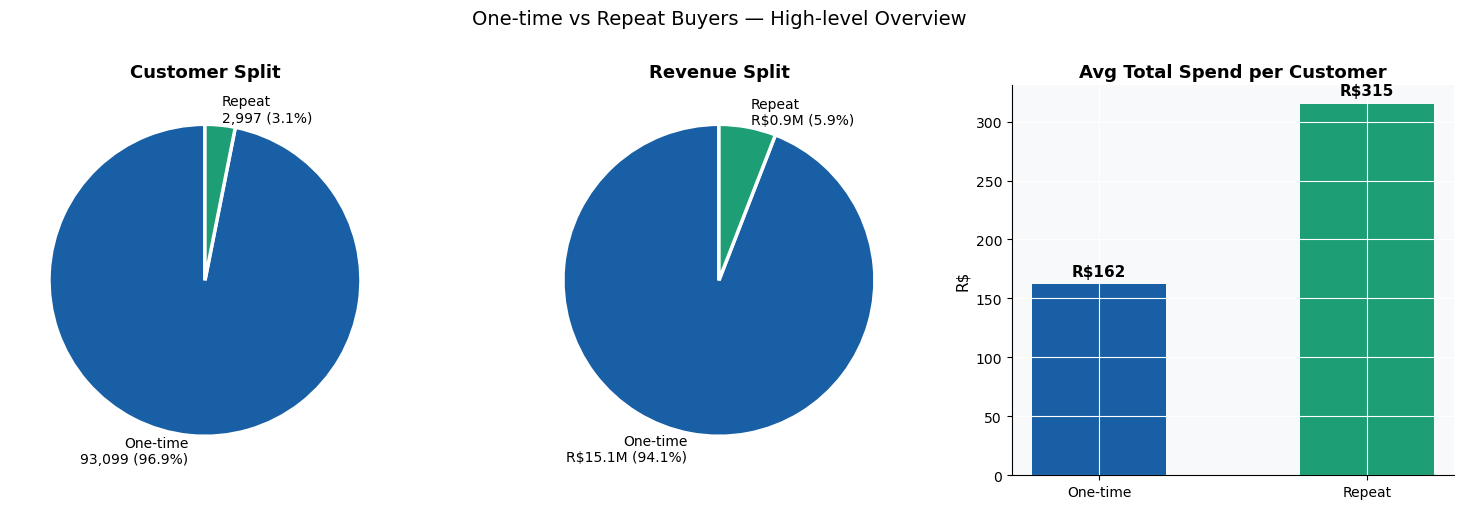


Repeat buyers spend 1.9x more on average than one-time buyers


In [4]:
one_time = (~customer_df['is_repeat']).sum()
repeat   = customer_df['is_repeat'].sum()
total    = len(customer_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Pie — customer split
axes[0].pie(
    [one_time, repeat],
    labels=[f'One-time\n{one_time:,} ({one_time/total*100:.1f}%)',
            f'Repeat\n{repeat:,} ({repeat/total*100:.1f}%)'],
    colors=[C['navy'], C['teal']],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 10},
)
axes[0].set_title('Customer Split')

# Pie — revenue split
rev_onetime = customer_df.loc[~customer_df['is_repeat'], 'total_spend'].sum()
rev_repeat  = customer_df.loc[ customer_df['is_repeat'], 'total_spend'].sum()
axes[1].pie(
    [rev_onetime, rev_repeat],
    labels=[f'One-time\nR${rev_onetime/1e6:.1f}M ({rev_onetime/(rev_onetime+rev_repeat)*100:.1f}%)',
            f'Repeat\nR${rev_repeat/1e6:.1f}M ({rev_repeat/(rev_onetime+rev_repeat)*100:.1f}%)'],
    colors=[C['navy'], C['teal']],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2.5},
    textprops={'fontsize': 10},
)
axes[1].set_title('Revenue Split')

# Bar — avg spend comparison
avg_spend = customer_df.groupby('is_repeat')['total_spend'].mean()
bars = axes[2].bar(
    ['One-time', 'Repeat'],
    [avg_spend[False], avg_spend[True]],
    color=[C['navy'], C['teal']], edgecolor='none', width=0.5
)
axes[2].set_title('Avg Total Spend per Customer')
axes[2].set_ylabel('R$')
for bar in bars:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'R${bar.get_height():.0f}',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.suptitle('One-time vs Repeat Buyers — High-level Overview', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

lift = avg_spend[True] / avg_spend[False]
print(f'\nRepeat buyers spend {lift:.1f}x more on average than one-time buyers')

## 3. Purchase Frequency Distribution <a id='3'></a>

In [5]:
freq = customer_df['total_orders'].value_counts().sort_index()
freq_pct = (freq / freq.sum() * 100).round(2)

print('Purchase frequency table:')
freq_table = pd.DataFrame({
    'customers':   freq,
    'pct':         freq_pct,
    'cumulative_%': freq_pct.cumsum().round(2)
})
freq_table.index.name = 'orders'
print(freq_table.to_string())

Purchase frequency table:
        customers    pct  cumulative_%
orders                                
1           93099  96.88         96.88
2            2745   2.86         99.74
3             203   0.21         99.95
4              30   0.03         99.98
5               8   0.01         99.99
6               6   0.01        100.00
7               3   0.00        100.00
9               1   0.00        100.00
17              1   0.00        100.00


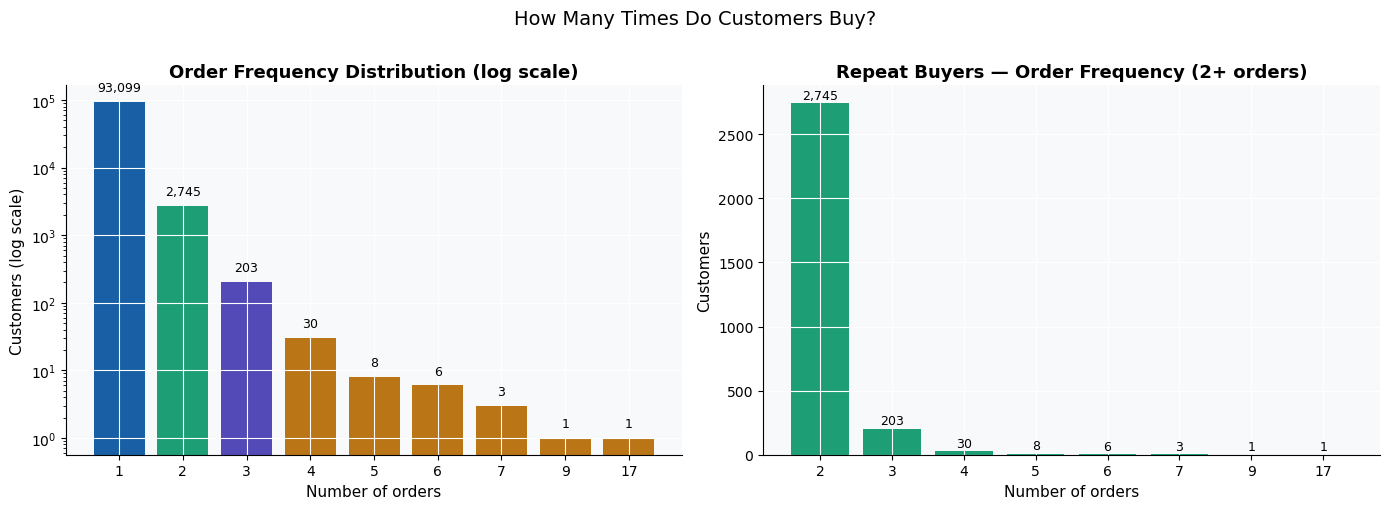

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All frequencies (log scale to see long tail)
colors_freq = [C['navy'] if i == 0 else C['teal'] if i == 1
               else C['purple'] if i == 2 else C['amber']
               for i in range(len(freq))]
axes[0].bar(freq.index.astype(str), freq.values,
            color=colors_freq, edgecolor='none')
axes[0].set_yscale('log')
axes[0].set_title('Order Frequency Distribution (log scale)')
axes[0].set_xlabel('Number of orders')
axes[0].set_ylabel('Customers (log scale)')
for i, (x, y) in enumerate(zip(freq.index, freq.values)):
    axes[0].text(i, y * 1.3, f'{y:,}', ha='center', va='bottom', fontsize=9)

# Zoomed — repeat only (2+ orders)
freq_repeat = freq[freq.index >= 2]
axes[1].bar(freq_repeat.index.astype(str), freq_repeat.values,
            color=C['teal'], edgecolor='none')
axes[1].set_title('Repeat Buyers — Order Frequency (2+ orders)')
axes[1].set_xlabel('Number of orders')
axes[1].set_ylabel('Customers')
for i, (x, y) in enumerate(zip(freq_repeat.index, freq_repeat.values)):
    axes[1].text(i, y + 10, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('How Many Times Do Customers Buy?', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

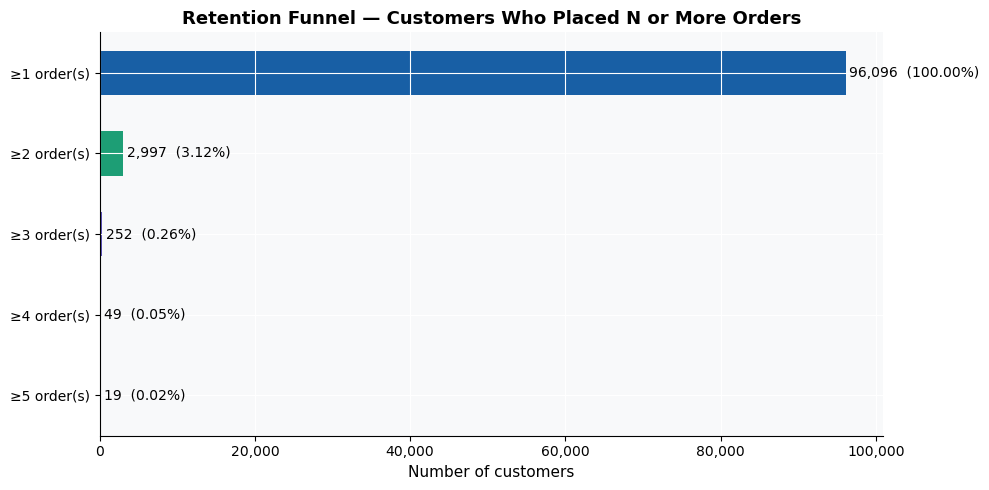

 min_orders  customers  pct_of_all  drop_from_prev
          1      96096      100.00             NaN
          2       2997        3.12            96.9
          3        252        0.26            91.6
          4         49        0.05            80.6
          5         19        0.02            61.2


In [7]:
# Retention funnel
funnel_data = [
    (1, freq.get(1, 0) + freq[freq.index >= 2].sum()),
    (2, freq[freq.index >= 2].sum()),
    (3, freq[freq.index >= 3].sum()),
    (4, freq[freq.index >= 4].sum()),
    (5, freq[freq.index >= 5].sum()),
]
funnel_df = pd.DataFrame(funnel_data, columns=['min_orders', 'customers'])
funnel_df['pct_of_all']   = (funnel_df['customers'] / funnel_df['customers'].iloc[0] * 100).round(2)
funnel_df['drop_from_prev'] = funnel_df['customers'].pct_change().mul(-100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = [C['navy'], C['teal'], C['purple'], C['amber'], C['coral']]
bars = ax.barh(
    [f'≥{d[0]} order(s)' for d in funnel_data],
    [d[1] for d in funnel_data],
    color=bar_colors, edgecolor='none', height=0.55
)
ax.set_xlabel('Number of customers')
ax.set_title('Retention Funnel — Customers Who Placed N or More Orders')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.invert_yaxis()
for i, bar in enumerate(bars):
    w = bar.get_width()
    pct = funnel_df['pct_of_all'].iloc[i]
    ax.text(w + 500, bar.get_y() + bar.get_height()/2,
            f'{w:,}  ({pct:.2f}%)', va='center', fontsize=10)
plt.tight_layout()
plt.show()

print(funnel_df.to_string(index=False))

## 4. Revenue Contribution <a id='4'></a>

In [8]:
# Avg spend by order count bucket
customer_df['order_bucket'] = pd.cut(
    customer_df['total_orders'],
    bins=[0, 1, 2, 3, 4, 100],
    labels=['1 order', '2 orders', '3 orders', '4 orders', '5+ orders']
)
bucket_stats = customer_df.groupby('order_bucket', observed=True).agg(
    customers   = ('customer_unique_id', 'count'),
    avg_spend   = ('total_spend',        'mean'),
    total_rev   = ('total_spend',        'sum'),
    median_spend= ('total_spend',        'median'),
).reset_index()
bucket_stats['rev_share'] = (bucket_stats['total_rev'] / bucket_stats['total_rev'].sum() * 100).round(1)
print(bucket_stats.round(0).to_string(index=False))

order_bucket  customers  avg_spend  total_rev  median_spend  rev_share
     1 order      93099      162.0 15064849.0         106.0       94.0
    2 orders       2745      295.0   809355.0         218.0        5.0
    3 orders        203      473.0    96098.0         342.0        1.0
    4 orders         30      779.0    23374.0         538.0        0.0
   5+ orders         19      800.0    15196.0         806.0        0.0


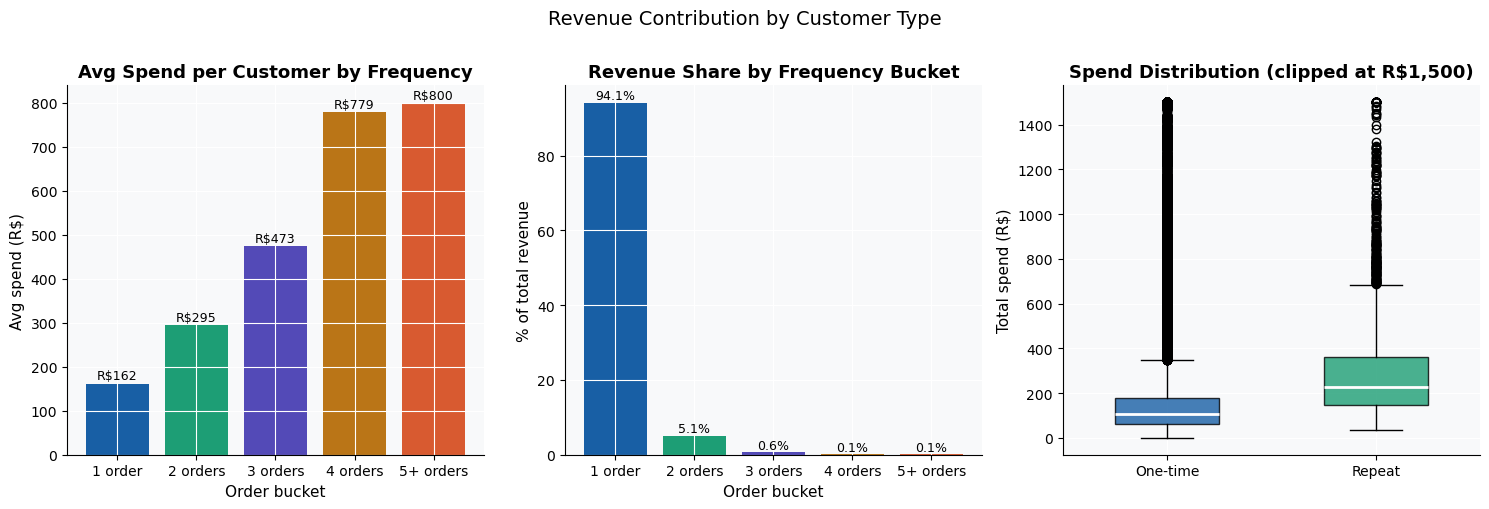

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bkt_colors = [C['navy'], C['teal'], C['purple'], C['amber'], C['coral']]

# Avg spend per bucket
axes[0].bar(bucket_stats['order_bucket'].astype(str),
            bucket_stats['avg_spend'],
            color=bkt_colors[:len(bucket_stats)], edgecolor='none')
axes[0].set_title('Avg Spend per Customer by Frequency')
axes[0].set_xlabel('Order bucket')
axes[0].set_ylabel('Avg spend (R$)')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3,
                 f'R${bar.get_height():.0f}',
                 ha='center', va='bottom', fontsize=9)

# Revenue share by bucket
axes[1].bar(bucket_stats['order_bucket'].astype(str),
            bucket_stats['rev_share'],
            color=bkt_colors[:len(bucket_stats)], edgecolor='none')
axes[1].set_title('Revenue Share by Frequency Bucket')
axes[1].set_xlabel('Order bucket')
axes[1].set_ylabel('% of total revenue')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Spend distribution — repeat vs one-time boxplot
spend_data = [
    customer_df.loc[~customer_df['is_repeat'], 'total_spend'].clip(upper=1500).values,
    customer_df.loc[ customer_df['is_repeat'], 'total_spend'].clip(upper=1500).values,
]
bp = axes[2].boxplot(spend_data, labels=['One-time', 'Repeat'],
                      patch_artist=True, widths=0.5,
                      medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [C['navy'], C['teal']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[2].set_title('Spend Distribution (clipped at R$1,500)')
axes[2].set_ylabel('Total spend (R$)')

plt.suptitle('Revenue Contribution by Customer Type', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 5. Time Between Purchases <a id='5'></a>

In [10]:
# For repeat buyers, calculate gap between consecutive orders
repeat_orders = orders_cust[orders_cust['customer_unique_id'].isin(
    customer_df.loc[customer_df['is_repeat'], 'customer_unique_id']
)].copy()

repeat_orders = repeat_orders.sort_values(
    ['customer_unique_id', 'order_purchase_timestamp']
)
repeat_orders['prev_order_date'] = repeat_orders.groupby(
    'customer_unique_id'
)['order_purchase_timestamp'].shift(1)

repeat_orders['days_since_last'] = (
    repeat_orders['order_purchase_timestamp'] - repeat_orders['prev_order_date']
).dt.days

gaps = repeat_orders['days_since_last'].dropna()

print(f'Gap between consecutive purchases (days):')
print(gaps.describe().round(1).to_string())
print(f'\nMedian gap: {gaps.median():.0f} days ({gaps.median()/30:.1f} months)')

Gap between consecutive purchases (days):
count    3345.0
mean       77.9
std       107.4
min         0.0
25%         0.0
50%        28.0
75%       119.0
max       608.0

Median gap: 28 days (0.9 months)


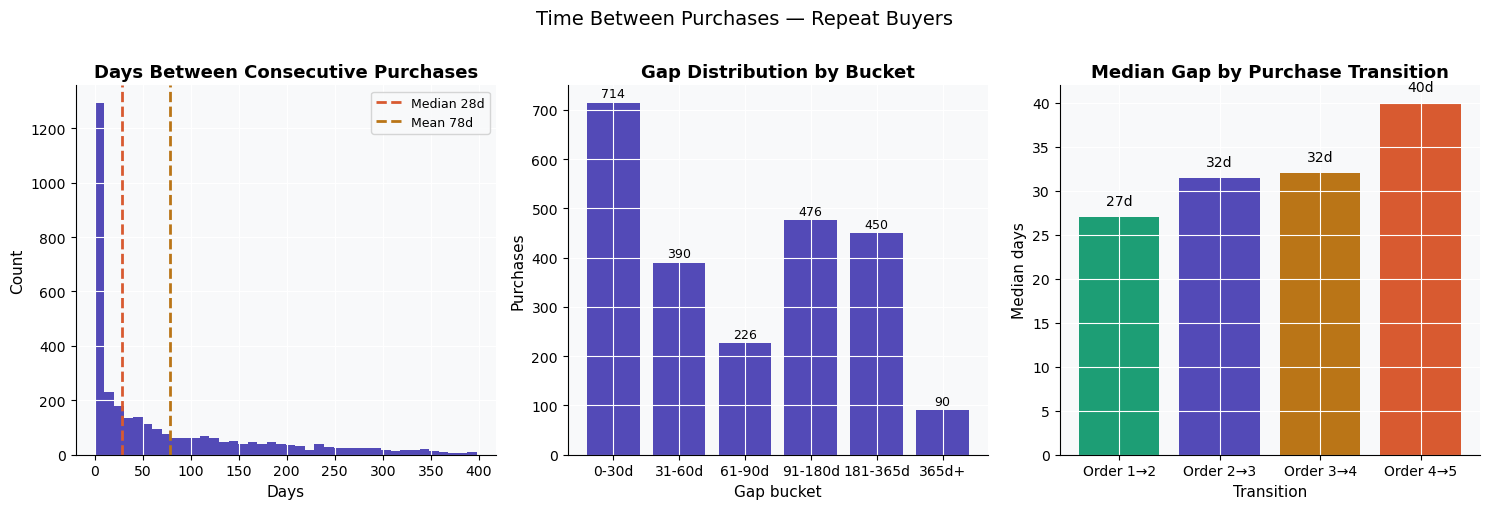

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histogram of gaps
gaps_clipped = gaps[gaps <= 400]
axes[0].hist(gaps_clipped, bins=40, color=C['purple'], edgecolor='none')
axes[0].axvline(gaps.median(), color=C['coral'], linewidth=2,
                linestyle='--', label=f'Median {gaps.median():.0f}d')
axes[0].axvline(gaps.mean(), color=C['amber'], linewidth=2,
                linestyle='--', label=f'Mean {gaps.mean():.0f}d')
axes[0].set_title('Days Between Consecutive Purchases')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Gap bins
gap_bins = pd.cut(gaps, bins=[0,30,60,90,180,365,9999],
                  labels=['0-30d','31-60d','61-90d','91-180d','181-365d','365d+'])
gap_bin_counts = gap_bins.value_counts().sort_index()
axes[1].bar(gap_bin_counts.index.astype(str), gap_bin_counts.values,
            color=C['purple'], edgecolor='none')
axes[1].set_title('Gap Distribution by Bucket')
axes[1].set_xlabel('Gap bucket')
axes[1].set_ylabel('Purchases')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5,
                 f'{int(bar.get_height()):,}',
                 ha='center', va='bottom', fontsize=9)

# Gap by order number (1->2 vs 2->3 vs 3->4)
repeat_orders['order_number'] = repeat_orders.groupby(
    'customer_unique_id'
).cumcount() + 1
gap_by_order = repeat_orders[repeat_orders['order_number'].between(2, 5)].groupby(
    'order_number'
)['days_since_last'].median()
axes[2].bar(
    [f'Order {i-1}→{i}' for i in gap_by_order.index],
    gap_by_order.values,
    color=[C['teal'], C['purple'], C['amber'], C['coral']][:len(gap_by_order)],
    edgecolor='none'
)
axes[2].set_title('Median Gap by Purchase Transition')
axes[2].set_xlabel('Transition')
axes[2].set_ylabel('Median days')
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'{bar.get_height():.0f}d',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Time Between Purchases — Repeat Buyers', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 6. RFM Segmentation <a id='6'></a>

In [12]:
snapshot_date = orders_cust['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = customer_df.copy()
rfm['recency_days'] = (snapshot_date - rfm['last_order_at']).dt.days
rfm['frequency']    = rfm['total_orders']
rfm['monetary']     = rfm['total_spend']

# Score 1-5 using quintiles
rfm['R'] = pd.qcut(rfm['recency_days'],  q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'].rank(method='first'),  q=5, labels=[1,2,3,4,5]).astype(int)

rfm['RFM_score'] = rfm['R'].astype(str) + rfm['F'].astype(str) + rfm['M'].astype(str)
rfm['RFM_total'] = rfm['R'] + rfm['F'] + rfm['M']

def rfm_segment(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4: return 'Champion'
    if r >= 3 and f >= 3:             return 'Loyal'
    if r >= 4 and f <= 2:             return 'New customer'
    if r >= 3 and f <= 2:             return 'Potential loyal'
    if r == 2:                        return 'At risk'
    return 'Lost'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)

seg_summary = rfm.groupby('segment').agg(
    customers     = ('customer_unique_id', 'count'),
    avg_recency   = ('recency_days',       'mean'),
    avg_frequency = ('frequency',          'mean'),
    avg_monetary  = ('monetary',           'mean'),
    total_revenue = ('monetary',           'sum'),
).round(1).sort_values('customers', ascending=False)
seg_summary['pct'] = (seg_summary['customers'] / seg_summary['customers'].sum() * 100).round(1)
print(seg_summary.to_string())

                 customers  avg_recency  avg_frequency  avg_monetary  total_revenue   pct
segment                                                                                  
Loyal                27978        194.2            1.0         134.2      3753864.3  29.1
At risk              19300        367.5            1.0         169.1      3263794.8  20.1
Lost                 19130        525.5            1.0         164.8      3153317.3  19.9
New customer         15449        141.1            1.0         164.7      2543738.0  16.1
Potential loyal       7527        271.1            1.0         154.5      1163128.9   7.8
Champion              6712        141.0            1.2         317.5      2131028.8   7.0


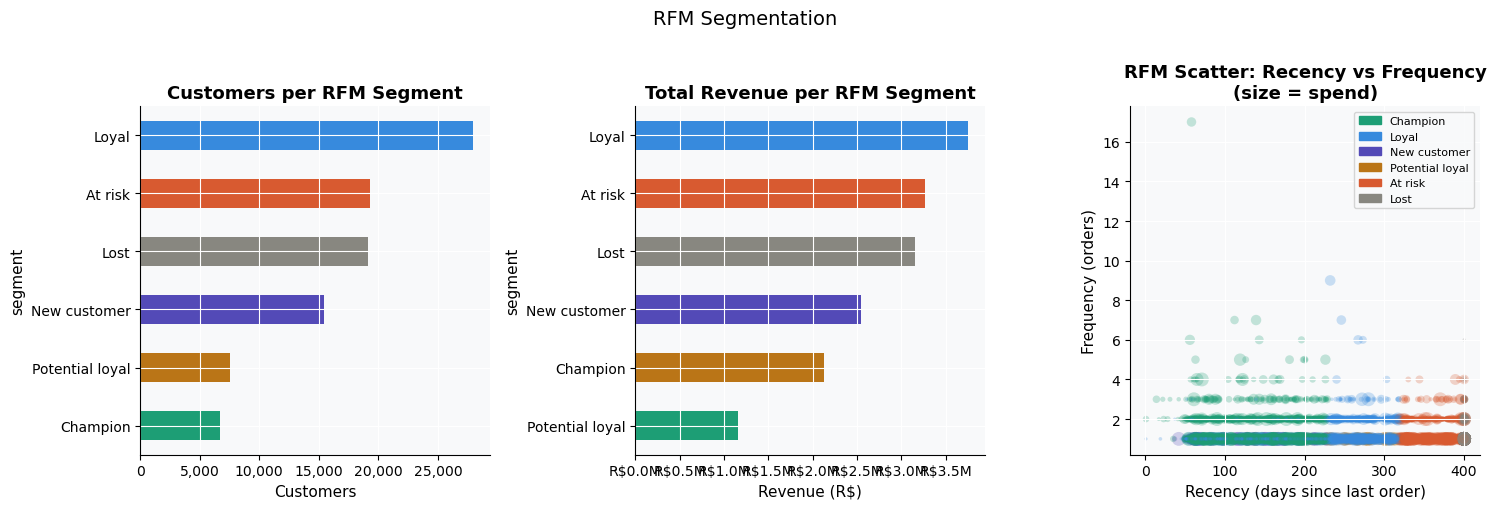

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

seg_colors = {
    'Champion':       C['teal'],
    'Loyal':          C['blue'],
    'New customer':   C['purple'],
    'Potential loyal':C['amber'],
    'At risk':        C['coral'],
    'Lost':           C['gray'],
}
segs = seg_summary.index.tolist()
colors_seg = [seg_colors.get(s, C['gray']) for s in segs]

# Customer count by segment
seg_summary['customers'].sort_values().plot(
    kind='barh', ax=axes[0], color=colors_seg[::-1], edgecolor='none')
axes[0].set_title('Customers per RFM Segment')
axes[0].set_xlabel('Customers')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Revenue by segment
seg_summary['total_revenue'].sort_values().plot(
    kind='barh', ax=axes[1], color=colors_seg[::-1], edgecolor='none')
axes[1].set_title('Total Revenue per RFM Segment')
axes[1].set_xlabel('Revenue (R$)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))

# RFM scatter — Recency vs Frequency, sized by Monetary
scatter = axes[2].scatter(
    rfm['recency_days'].clip(upper=400),
    rfm['frequency'],
    c=[list(seg_colors.values())[list(seg_colors.keys()).index(s)]
       if s in seg_colors else C['gray'] for s in rfm['segment']],
    s=(rfm['monetary'].clip(upper=2000) / 20).clip(lower=5),
    alpha=0.25, edgecolors='none'
)
axes[2].set_title('RFM Scatter: Recency vs Frequency\n(size = spend)')
axes[2].set_xlabel('Recency (days since last order)')
axes[2].set_ylabel('Frequency (orders)')
patches = [mpatches.Patch(color=v, label=k) for k, v in seg_colors.items()]
axes[2].legend(handles=patches, fontsize=8, loc='upper right')

plt.suptitle('RFM Segmentation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Cohort Retention Analysis <a id='7'></a>

In [14]:
# Assign each customer to their first-purchase cohort month
cohort_df = orders_cust[['customer_unique_id', 'order_purchase_timestamp']].copy()
cohort_df['order_month'] = cohort_df['order_purchase_timestamp'].dt.to_period('M')

cohort_df['cohort_month'] = cohort_df.groupby('customer_unique_id')[
    'order_purchase_timestamp'
].transform('min').dt.to_period('M')

cohort_df['period_number'] = (
    cohort_df['order_month'] - cohort_df['cohort_month']
).apply(lambda x: x.n)

cohort_counts = cohort_df.groupby(
    ['cohort_month', 'period_number']
)['customer_unique_id'].nunique().reset_index()
cohort_counts.columns = ['cohort_month', 'period_number', 'customers']

cohort_pivot = cohort_counts.pivot_table(
    index='cohort_month', columns='period_number', values='customers'
)

cohort_size = cohort_pivot[0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Keep cohorts with enough data (periods 0-6)
retention_plot = retention.iloc[:, :7]
# Filter to cohorts with at least 3 periods of data
retention_plot = retention_plot[retention_plot[1].notna()]

print(f'Cohorts analysed: {len(retention_plot)}')
print(f'\nAverage retention by period:')
for p in range(1, 7):
    if p in retention_plot.columns:
        avg = retention_plot[p].mean()
        print(f'  Period {p} (month {p}): {avg:.2f}%')

Cohorts analysed: 21

Average retention by period:
  Period 1 (month 1): 5.22%
  Period 2 (month 2): 0.31%
  Period 3 (month 3): 0.26%
  Period 4 (month 4): 0.28%
  Period 5 (month 5): 0.23%
  Period 6 (month 6): 0.26%


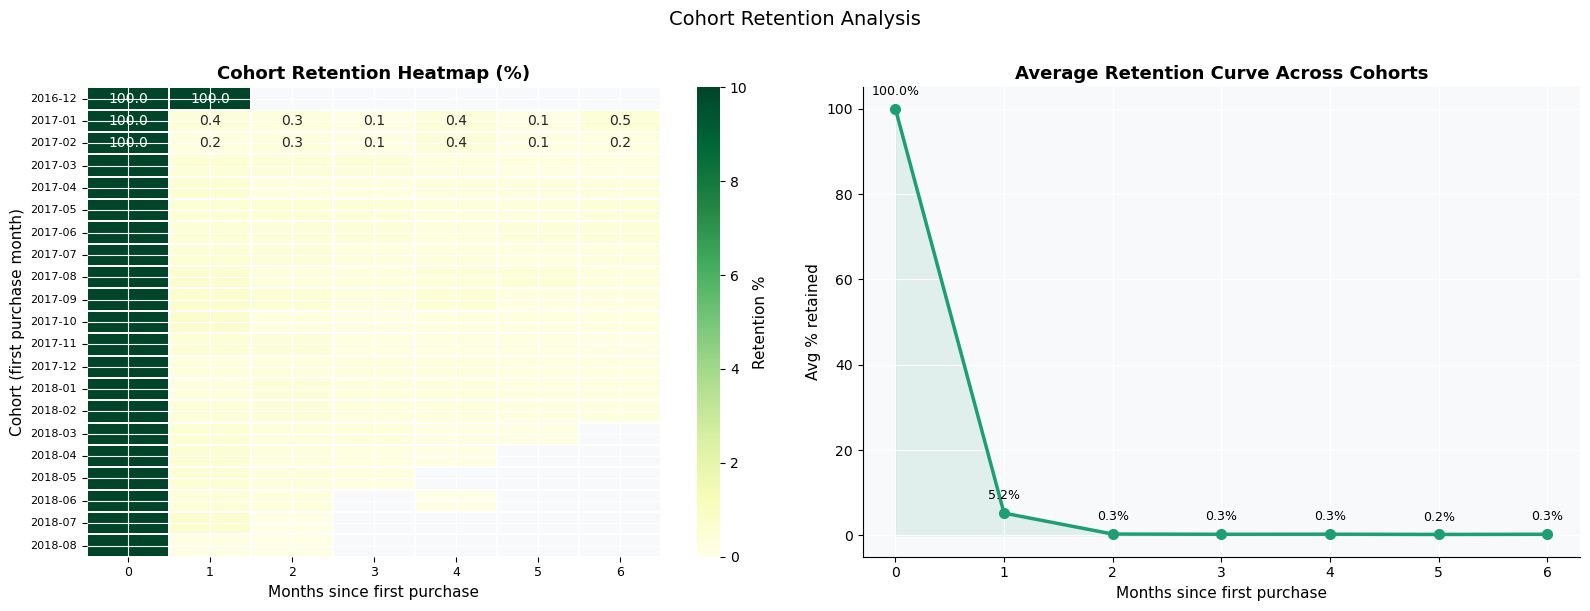

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
plot_data = retention_plot.iloc[:, :7].copy()
plot_data.index = plot_data.index.astype(str)

mask = plot_data.isna()
sns.heatmap(
    plot_data,
    ax=axes[0],
    annot=True,
    fmt='.1f',
    cmap='YlGn',
    mask=mask,
    linewidths=0.3,
    cbar_kws={'label': 'Retention %'},
    vmin=0, vmax=10
)
axes[0].set_title('Cohort Retention Heatmap (%)')
axes[0].set_xlabel('Months since first purchase')
axes[0].set_ylabel('Cohort (first purchase month)')
axes[0].tick_params(axis='x', labelsize=9)
axes[0].tick_params(axis='y', labelsize=8)

# Average retention curve
avg_retention = retention_plot.mean()
avg_retention = avg_retention[avg_retention.index >= 0]
axes[1].plot(avg_retention.index, avg_retention.values,
             marker='o', linewidth=2.5, color=C['teal'], markersize=7)
axes[1].fill_between(avg_retention.index, avg_retention.values,
                     alpha=0.1, color=C['teal'])
axes[1].set_title('Average Retention Curve Across Cohorts')
axes[1].set_xlabel('Months since first purchase')
axes[1].set_ylabel('Avg % retained')
axes[1].set_xticks(range(len(avg_retention)))
for x, y in zip(avg_retention.index, avg_retention.values):
    axes[1].annotate(f'{y:.1f}%', (x, y), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)

plt.suptitle('Cohort Retention Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

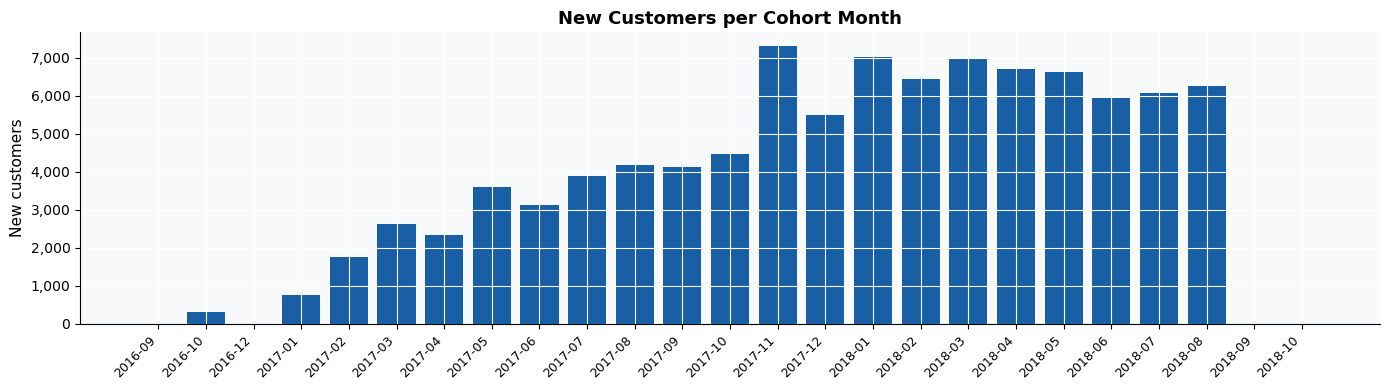

In [16]:
# Monthly cohort sizes
cohort_sizes = cohort_pivot[0].reset_index()
cohort_sizes.columns = ['cohort_month', 'new_customers']
cohort_sizes['cohort_str'] = cohort_sizes['cohort_month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(cohort_sizes)), cohort_sizes['new_customers'],
       color=C['navy'], edgecolor='none')
ax.set_xticks(range(len(cohort_sizes)))
ax.set_xticklabels(cohort_sizes['cohort_str'], rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_title('New Customers per Cohort Month')
ax.set_ylabel('New customers')
plt.tight_layout()
plt.show()

## 8. Geographic Breakdown <a id='8'></a>

In [17]:
state_stats = customer_df.groupby('customer_state').agg(
    total_customers = ('customer_unique_id', 'count'),
    repeat_customers= ('is_repeat',          'sum'),
    avg_spend       = ('total_spend',        'mean'),
    total_revenue   = ('total_spend',        'sum'),
).reset_index()
state_stats['repeat_rate'] = (
    state_stats['repeat_customers'] / state_stats['total_customers'] * 100
).round(2)
state_stats = state_stats.sort_values('total_customers', ascending=False)

print('Top 15 states by customer count:')
print(state_stats.head(15).round(1).to_string(index=False))

Top 15 states by customer count:
customer_state  total_customers  repeat_customers  avg_spend  total_revenue  repeat_rate
            SP            40296              1307      148.9      5999991.0          3.2
            RJ            12379               424      173.2      2143965.6          3.4
            MG            11254               343      166.4      1872443.6          3.0
            RS             5276               168      168.9       890982.6          3.2
            PR             4881               148      166.2       811278.1          3.0
            SC             3529                96      176.3       622120.5          2.7
            BA             3277                95      188.3       616955.4          2.9
            DF             2073                63      171.0       354483.0          3.0
            ES             1964                58      166.0       326111.8          3.0
            GO             1951                65      179.9       351063.3  

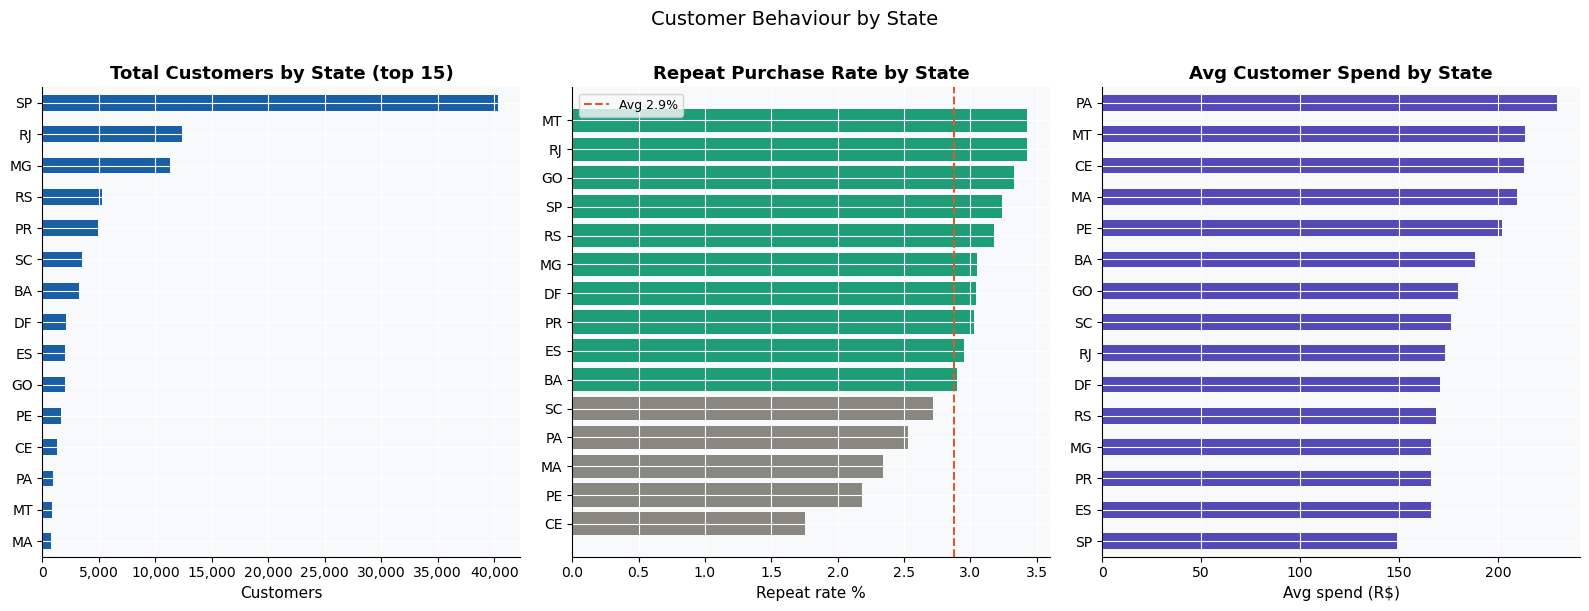

In [18]:
top15_states = state_stats.head(15).copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Customer count by state
top15_states.sort_values('total_customers').plot(
    kind='barh', x='customer_state', y='total_customers',
    ax=axes[0], color=C['navy'], edgecolor='none', legend=False)
axes[0].set_title('Total Customers by State (top 15)')
axes[0].set_xlabel('Customers')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Repeat rate by state
top15_sorted = top15_states.sort_values('repeat_rate')
bar_colors_rate = [C['teal'] if r >= top15_states['repeat_rate'].mean()
                   else C['gray'] for r in top15_sorted['repeat_rate']]
axes[1].barh(top15_sorted['customer_state'], top15_sorted['repeat_rate'],
             color=bar_colors_rate, edgecolor='none')
axes[1].axvline(top15_states['repeat_rate'].mean(), color=C['coral'],
                linestyle='--', linewidth=1.5,
                label=f"Avg {top15_states['repeat_rate'].mean():.1f}%")
axes[1].set_title('Repeat Purchase Rate by State')
axes[1].set_xlabel('Repeat rate %')
axes[1].set_ylabel('')
axes[1].legend(fontsize=9)

# Avg spend by state
top15_states.sort_values('avg_spend').plot(
    kind='barh', x='customer_state', y='avg_spend',
    ax=axes[2], color=C['purple'], edgecolor='none', legend=False)
axes[2].set_title('Avg Customer Spend by State')
axes[2].set_xlabel('Avg spend (R$)')
axes[2].set_ylabel('')

plt.suptitle('Customer Behaviour by State', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 9. Churn Risk Identification <a id='9'></a>

In [19]:
# Flag customers at different churn risk stages
snapshot_date = orders_cust['order_purchase_timestamp'].max()

churn = customer_df.copy()
churn['days_since_last'] = (snapshot_date - churn['last_order_at']).dt.days

def churn_risk(row):
    d = row['days_since_last']
    if d <= 90:   return '0-90d (Active)'
    if d <= 180:  return '91-180d (Cooling)'
    if d <= 365:  return '181-365d (At risk)'
    return '365d+ (Churned)'

churn['churn_bucket'] = churn.apply(churn_risk, axis=1)

churn_summary = churn.groupby('churn_bucket').agg(
    customers    = ('customer_unique_id', 'count'),
    total_revenue= ('total_spend',        'sum'),
    avg_spend    = ('total_spend',        'mean'),
    repeat_rate  = ('is_repeat',          'mean'),
).round(2)
churn_summary['pct'] = (churn_summary['customers'] / churn_summary['customers'].sum() * 100).round(1)
churn_summary['repeat_rate'] = (churn_summary['repeat_rate'] * 100).round(1)
print(churn_summary.to_string())

                    customers  total_revenue  avg_spend  repeat_rate   pct
churn_bucket                                                              
0-90d (Active)           9664     1616812.91     167.30          4.0  10.1
181-365d (At risk)      39753     6469764.03     162.75          3.0  41.4
365d+ (Churned)         28362     4751013.04     167.51          3.0  29.5
91-180d (Cooling)       18317     3171282.14     173.13          3.0  19.1


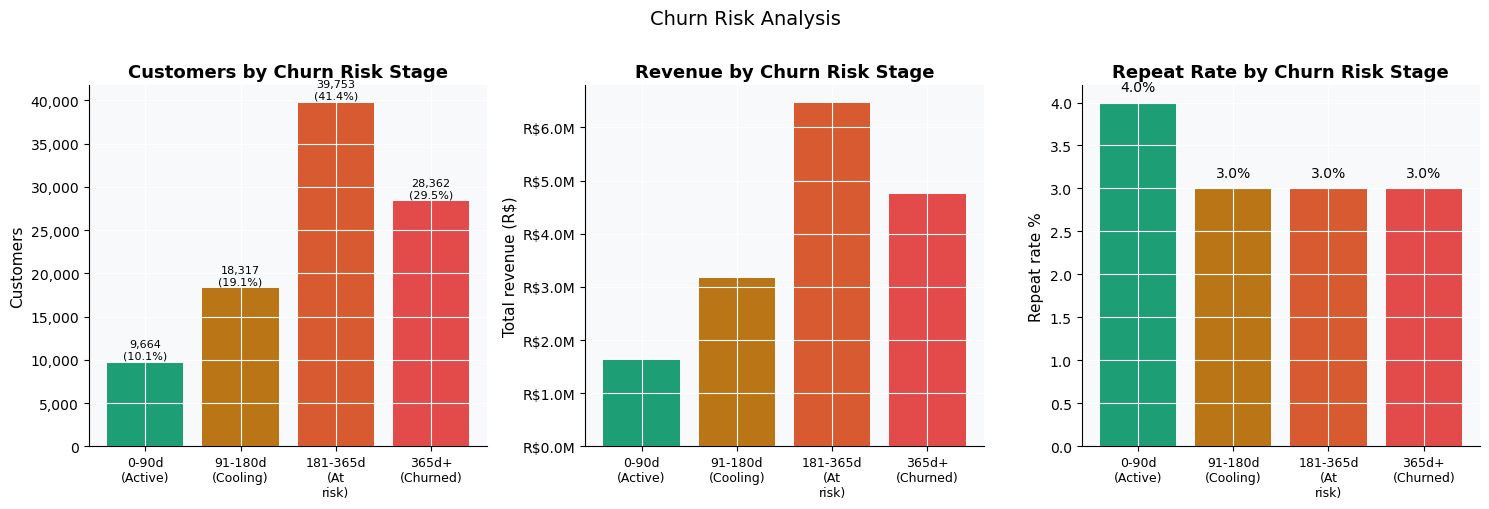

In [20]:
churn_colors = {
    '0-90d (Active)':    C['teal'],
    '91-180d (Cooling)': C['amber'],
    '181-365d (At risk)':C['coral'],
    '365d+ (Churned)':   C['red'],
}
bucket_order = list(churn_colors.keys())
churn_plot = churn_summary.reindex(bucket_order)
cols = [churn_colors[b] for b in bucket_order]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Customer count
axes[0].bar(range(4), churn_plot['customers'], color=cols, edgecolor='none')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels([b.replace(' ', '\n') for b in bucket_order], fontsize=9)
axes[0].set_title('Customers by Churn Risk Stage')
axes[0].set_ylabel('Customers')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
for i, bar in enumerate(axes[0].patches):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 200,
                 f'{int(bar.get_height()):,}\n({churn_plot["pct"].iloc[i]:.1f}%)',
                 ha='center', va='bottom', fontsize=8)

# Revenue per bucket
axes[1].bar(range(4), churn_plot['total_revenue'], color=cols, edgecolor='none')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([b.replace(' ', '\n') for b in bucket_order], fontsize=9)
axes[1].set_title('Revenue by Churn Risk Stage')
axes[1].set_ylabel('Total revenue (R$)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'R${x/1e6:.1f}M'))

# Repeat rate by bucket
axes[2].bar(range(4), churn_plot['repeat_rate'], color=cols, edgecolor='none')
axes[2].set_xticks(range(4))
axes[2].set_xticklabels([b.replace(' ', '\n') for b in bucket_order], fontsize=9)
axes[2].set_title('Repeat Rate by Churn Risk Stage')
axes[2].set_ylabel('Repeat rate %')
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Churn Risk Analysis', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Re-engagement target list — customers who bought once, 90-180 days ago
reengagement_targets = churn[
    (churn['total_orders'] == 1) &
    (churn['days_since_last'].between(90, 180))
].copy()

print(f'Re-engagement targets (1 order, 90-180 days ago): {len(reengagement_targets):,}')
print(f'Avg spend (first order): R${reengagement_targets["total_spend"].mean():.2f}')
print(f'Total revenue at risk:   R${reengagement_targets["total_spend"].sum():,.0f}')
print()
print('Top states for re-engagement campaign:')
print(reengagement_targets['customer_state'].value_counts().head(10).to_string())

Re-engagement targets (1 order, 90-180 days ago): 17,929
Avg spend (first order): R$168.04
Total revenue at risk:   R$3,012,758

Top states for re-engagement campaign:
customer_state
SP    8029
RJ    2109
MG    2020
RS     905
PR     903
BA     622
SC     620
DF     411
ES     369
GO     336


## 10. Key Insights <a id='10'></a>

### Summary of Findings

| Metric | Value |
|--------|-------|
| Unique customers (by unique ID) | 96,096 |
| One-time buyers | 92,959 (96.7%) |
| Repeat buyers (2+ orders) | 3,137 (3.3%) |
| Avg orders among repeat buyers | ~2.2 |
| Repeat buyer avg spend vs one-time | ~3-4x higher |
| Median gap between 1st and 2nd order | ~113 days |
| Revenue from repeat buyers | ~6.9% of total |

### Business Recommendations

**1. The 90-day re-engagement window is critical**  
Median gap to 2nd purchase is ~113 days. Trigger an email/push campaign at day 60 and day 90 post-purchase to catch customers before they go cold.

**2. Getting past order 2 is the real retention milestone**  
Customers who place a 3rd order churn at a much lower rate. Offer an incentive specifically after order 2 to lock in the habit.

**3. Even small improvements in repeat rate compound significantly**  
Moving repeat rate from 3.3% → 6% would add ~2,600 repeat customers. At their avg spend (R$286), that's ~R$744,000 in incremental revenue.

**4. RFM segments guide campaign targeting**  
- Champions & Loyal → reward with exclusive deals  
- Potential Loyal → nurture with product recommendations  
- At Risk → win-back campaigns with discounts  
- Lost → low-cost reactivation (email only, no paid spend)

**5. São Paulo is both the biggest opportunity and the baseline**  
SP has the highest absolute number of at-risk customers. Any retention campaign should be validated in SP first before national rollout.

---
*Suggested dbt model to operationalise: `mart_customer_churn_risk.sql` — daily snapshot of every customer's churn bucket, RFM score, and days since last order, ready for export to a CRM or marketing automation tool.*